In [14]:
import pandas as pd
import joblib
import shap

In [15]:
model = joblib.load("../model.pkl")

In [16]:
df = pd.read_csv("../data/merged_dataset.csv")

In [17]:
X = df[
    [
        "Reviews",
        "Installs",
        "Size",
        "Price",
        "App_Age",
        "Review_Ratio",
        "Log_Reviews",
        "Log_Installs",
        "Paid_App",
        "Sentiment_Polarity",
        "Sentiment_Subjectivity"
    ]
]

In [18]:
explainer = shap.TreeExplainer(model)

In [19]:
X_sample = X.sample(n=500, random_state=42)

shap_values = explainer.shap_values(X_sample)

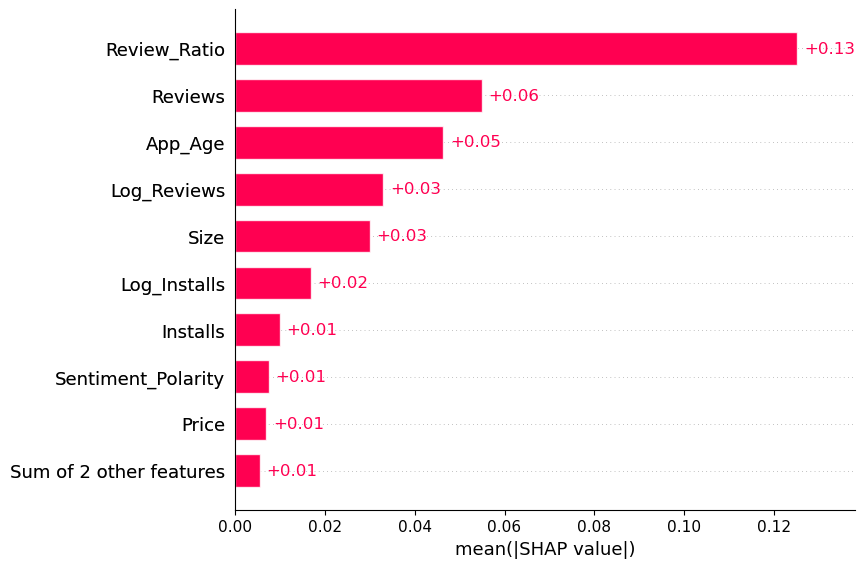

In [20]:
shap.plots.bar(shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X,
    feature_names=X.columns
))

In [21]:
sample = X.iloc[[0]]
sample

,Reviews,Installs,Size,Price,App_Age,Review_Ratio,Log_Reviews,Log_Installs,Paid_App,Sentiment_Polarity,Sentiment_Subjectivity
0,159.0,10000.0,19.0,0.0,213,0.0159,5.075174,9.21044,0,0.0,0.0


In [22]:
sample_shap = explainer(sample)

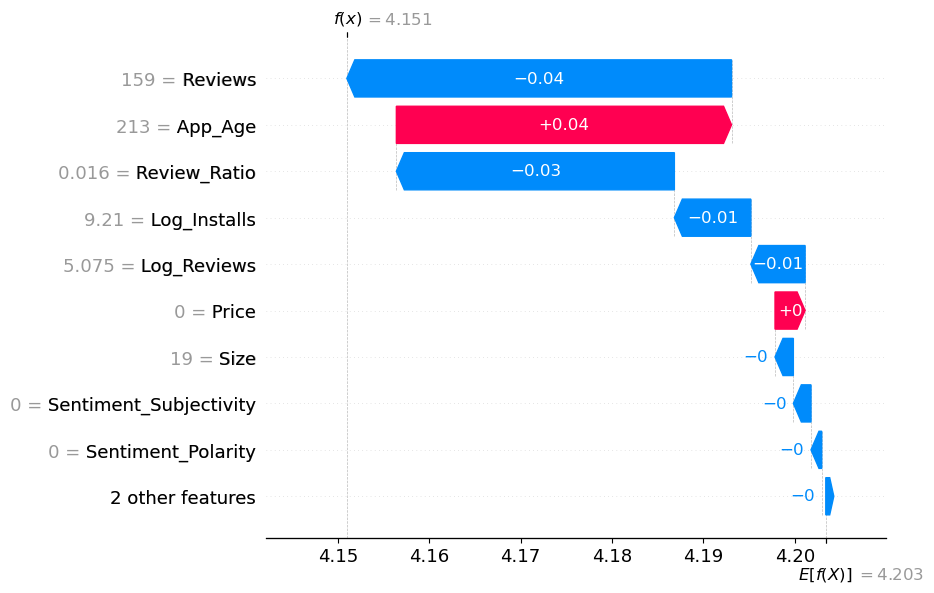

In [23]:
shap.plots.waterfall(sample_shap[0])

In [24]:
row = 0

print("App:", df.iloc[row]["App"])
print("Actual Rating:", df.iloc[row]["Rating"])
print("Predicted Rating:", model.predict(sample)[0])

App: Photo Editor & Candy Camera & Grid & ScrapBook
Actual Rating: 4.1
Predicted Rating: 4.150999999999997


In [25]:
app_name = df.iloc[0]["App"]

prediction = model.predict(sample)

print("App:", app_name)
print("Predicted Rating:", prediction[0])

App: Photo Editor & Candy Camera & Grid & ScrapBook
Predicted Rating: 4.150999999999997


## Explainable AI Insights

- Reviews had the greatest influence on predicted ratings.
- Positive user sentiment significantly improved predictions.
- Apps with more installs generally received higher predicted ratings.
- Price had a comparatively smaller effect on ratings.
- Recently updated apps tended to achieve better predicted ratings.